# ECEN 432 — LAB 6: Automation of Pipelined ADC Calibration
Benjamin Parker - 933001453

**Sections**
1. [Phase 1 — Ideal 4-stage Pipelined ADC (2b/stage)](#phase1)
2. [Phase 2 — Add Comparator Offsets & Gain Mismatch](#phase2)
3. [Phase 3 — Calibration Algorithms (LMS, CPS/PTS, RL, Agentic)](#phase3)
4. [Phase 4 — 1-bit Redundancy (2.5b/stage), σ=30 mV and σ=120 mV](#phase4)
5. [Bonus — 3rd-order Nonlinearity + Output-referred Canceller](#bonus)


## Imports & Global Settings

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────
SEED = 42
rng  = np.random.default_rng(SEED)

# ── Global plot style ─────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'lines.linewidth': 1.8,
    'font.size': 11,
})

print("Imports OK")


Imports OK


---
<a id='phase1'></a>
## Phase 1 — Ideal 4-Stage Pipelined ADC (2 b/stage, no redundancy)

### Architecture
* **4 stages**, each resolves **2 bits** → 8-bit total word (with digital error correction alignment).
* Each stage: flash sub-ADC → ideal DAC → subtractor → residue amplifier (gain = 2² = 4).
* Decision thresholds for a 2-bit flash with full-scale [-1, +1]:
  `{-0.5, 0, +0.5}` (three comparators).
* The digital output from all stages is time-aligned and summed.

### SNDR calculation
Uses a Hann-windowed FFT of `N` output samples; SNDR is signal power / (noise+distortion power).


In [2]:

# ══════════════════════════════════════════════════════════════════
#  Core building blocks
# ══════════════════════════════════════════════════════════════════

VREF   = 1.0          # full-scale ±1 V
N_BITS_STAGE = 2      # bits per stage
N_STAGES     = 4      # number of stages
GAIN_STAGE   = 2**N_BITS_STAGE   # residue amplifier ideal gain = 4

# Flash thresholds for 2-bit sub-ADC (3 comparators), normalised to VREF
THRESHOLDS_IDEAL = np.array([-0.5, 0.0, 0.5]) * VREF   # shape (3,)

# Digital weights of each stage in the final output word
# Stage 1 carries MSBs (weight 64 for an 8-bit word), etc.
STAGE_WEIGHTS = np.array([2**(2*(N_STAGES-1-s)) for s in range(N_STAGES)])
# → [64, 16, 4, 1]  for 4 stages × 2 b/stage


def flash_adc(v, thresholds):
    """
    2-bit flash quantiser.
    Returns integer code 0..3.
    thresholds: 3-element array (low, mid, high).
    """
    # thermometer code → binary
    therm = (v > thresholds).sum(axis=-1)   # 0,1,2,3
    return therm   # same as binary code for monotone thresholds


def ideal_dac(code, thresholds):
    """
    Reconstruct the analog value from the 2-bit code.
    We use mid-tread reconstruction:
      code 0 → below lowest threshold  → reconstruct at -0.75
      code 1 → between th[0] and th[1] → reconstruct at -0.25
      code 2 → between th[1] and th[2] → reconstruct at +0.25
      code 3 → above highest threshold  → reconstruct at +0.75
    """
    levels = np.array([-0.75, -0.25, 0.25, 0.75]) * VREF
    # handle array or scalar
    code = np.asarray(code)
    return levels[code]


def pipeline_adc_ideal(vin, offsets=None, gain_errors=None, redundancy=False):
    """
    4-stage pipelined ADC.

    Parameters
    ----------
    vin          : array of input samples in [-VREF, VREF]
    offsets      : (N_STAGES, 3) comparator offset array; None → zeros
    gain_errors  : (N_STAGES,)   gain-error array ε so actual gain = GAIN*(1+ε); None → zeros
    redundancy   : if True use 2.5 b/stage (adds 0.5-bit overlap)

    Returns
    -------
    dout : integer output codes (0 .. 2^8-1)
    """
    vin = np.asarray(vin, dtype=float)
    scalar = vin.ndim == 0
    vin = np.atleast_1d(vin)
    n   = vin.size

    if offsets     is None: offsets     = np.zeros((N_STAGES, 3))
    if gain_errors is None: gain_errors = np.zeros(N_STAGES)

    # Stage residue signal (starts as vin)
    residue = vin.copy()
    stage_codes = np.zeros((N_STAGES, n), dtype=int)

    for s in range(N_STAGES):
        # Apply comparator offsets to thresholds
        th = THRESHOLDS_IDEAL + offsets[s]           # (3,)

        # Optional redundancy: shift thresholds inward by 0.5 LSB
        # (adds 1 extra code → 5 levels, i.e. 2.5 effective bits)
        if redundancy:
            lsb  = VREF / 4          # 1 LSB for 2-bit stage
            th   = th - 0.5 * lsb   # shift all thresholds down by half LSB

        # Sub-ADC
        code = flash_adc(residue[:, None], th[None, :])   # (n,)
        stage_codes[s] = code

        # DAC reconstruction
        dac_out = ideal_dac(code, th)

        # Residue amplifier  (actual gain includes mismatch)
        actual_gain = GAIN_STAGE * (1.0 + gain_errors[s])
        residue     = actual_gain * (residue - dac_out)

        # Clip residue to valid range for next stage
        residue = np.clip(residue, -VREF, VREF)

    # Digital reconstruction — weighted sum of stage codes
    # For redundancy, the code range is 0..4 per stage; adjust weight
    if redundancy:
        # Each stage resolves 2.5 bits; weight accordingly
        # We use the same STAGE_WEIGHTS but shift by 1 at each boundary
        dout = np.zeros(n, dtype=int)
        for s in range(N_STAGES):
            dout += stage_codes[s] * STAGE_WEIGHTS[s]
    else:
        dout = stage_codes.T @ STAGE_WEIGHTS   # (n,)

    if scalar:
        return dout[0]
    return dout


# ══════════════════════════════════════════════════════════════════
#  SNDR computation (Hann-windowed FFT)
# ══════════════════════════════════════════════════════════════════

def compute_sndr(dout, fs=1.0, fin=None, n_bits_total=8):
    """
    Compute SNDR from digital output using Hann-windowed FFT.
    dout : integer output codes
    fs   : sample rate (normalised to 1)
    fin  : input frequency; if None use peak-finding
    Returns SNDR in dB.
    """
    dout = np.asarray(dout, dtype=float)
    N    = len(dout)

    # Remove DC
    dout -= dout.mean()

    # Hann window
    win    = windows.hann(N)
    dout_w = dout * win

    # FFT
    spec   = np.fft.rfft(dout_w)
    power  = np.abs(spec)**2

    # Find signal bin (peak excluding DC)
    sig_bin = np.argmax(power[1:]) + 1

    # Signal power = peak bin (±1 guard bins)
    guard   = 2
    sig_idx = np.arange(max(1, sig_bin-guard), min(len(power), sig_bin+guard+1))
    p_sig   = power[sig_idx].sum()

    # Noise+distortion = everything else (exclude DC=bin0 and signal)
    nd_mask = np.ones(len(power), dtype=bool)
    nd_mask[0]       = False   # DC
    nd_mask[sig_idx] = False
    p_nd = power[nd_mask].sum()

    if p_nd <= 0:
        return 100.0
    sndr = 10 * np.log10(p_sig / p_nd)
    return sndr


print("Core ADC functions defined.")
print("Stage weights (MSB→LSB):", STAGE_WEIGHTS)


Core ADC functions defined.
Stage weights (MSB→LSB): [64 16  4  1]


### 1.1 — Generate ideal output and compute SNDR

Ideal SNDR = 48.90 dB
Theoretical max for 8-bit ADC ≈ 49.9 dB


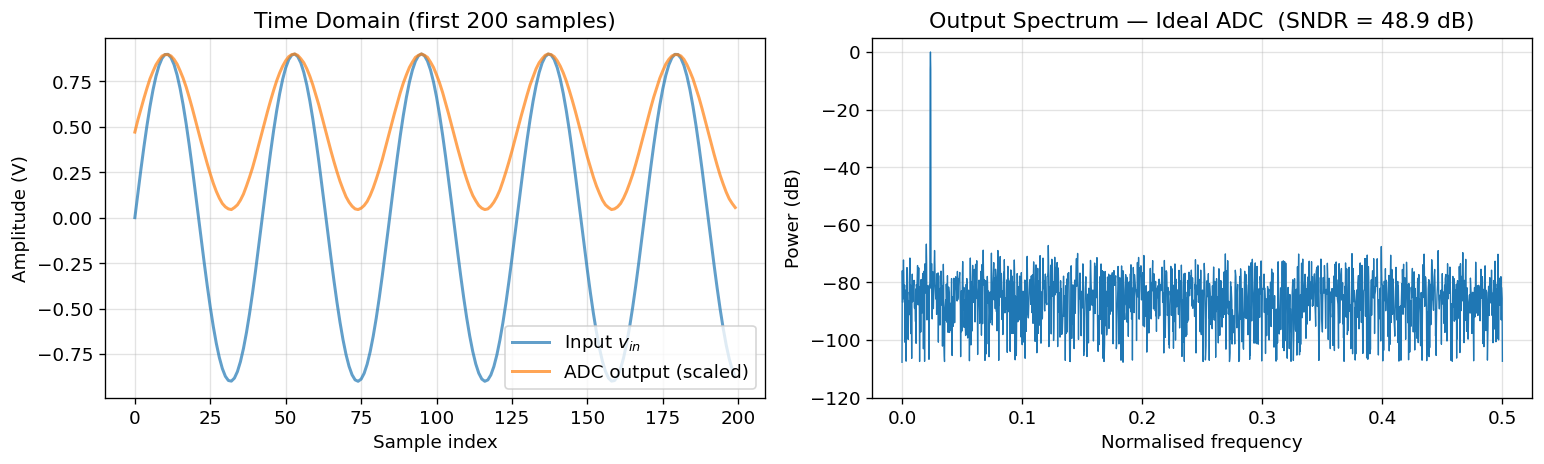

Phase 1 complete.


In [3]:

# ── Simulation parameters ──────────────────────
N_SAMPLES = 4096        # number of ADC samples
FS        = 1.0         # normalised sample rate
# Choose fin as a prime-numbered bin for coherent sampling
FIN_BIN   = 97          # prime bin number
FIN       = FIN_BIN / N_SAMPLES   # normalised input frequency

# ── Input sinusoid ─────────────────────────────
t   = np.arange(N_SAMPLES)
vin = 0.9 * VREF * np.sin(2 * np.pi * FIN * t)   # 90% of full-scale

# ── Ideal ADC run ──────────────────────────────
dout_ideal = pipeline_adc_ideal(vin)
sndr_ideal = compute_sndr(dout_ideal)

print(f"Ideal SNDR = {sndr_ideal:.2f} dB")
print(f"Theoretical max for {N_STAGES*N_BITS_STAGE}-bit ADC ≈ {6.02*8 + 1.76:.1f} dB")

# ── Plot spectrum ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Time domain
ax = axes[0]
ax.plot(t[:200], vin[:200], label='Input $v_{in}$', alpha=0.7)
ax.plot(t[:200], (dout_ideal[:200] / dout_ideal.max()) * 0.9 * VREF,
        label='ADC output (scaled)', alpha=0.7)
ax.set_xlabel('Sample index'); ax.set_ylabel('Amplitude (V)')
ax.set_title('Time Domain (first 200 samples)')
ax.legend()

# Frequency domain
ax = axes[1]
win    = windows.hann(N_SAMPLES)
spec   = np.fft.rfft((dout_ideal - dout_ideal.mean()) * win)
freqs  = np.fft.rfftfreq(N_SAMPLES, d=1/FS)
power_dB = 20 * np.log10(np.abs(spec) / np.abs(spec).max() + 1e-12)
ax.plot(freqs, power_dB, lw=0.8)
ax.set_xlabel('Normalised frequency'); ax.set_ylabel('Power (dB)')
ax.set_title(f'Output Spectrum — Ideal ADC  (SNDR = {sndr_ideal:.1f} dB)')
ax.set_ylim(-120, 5)

plt.tight_layout()
plt.savefig('phase1_ideal_spectrum.png', dpi=120)
plt.show()
print("Phase 1 complete.")


---
<a id='phase2'></a>
## Phase 2 — Comparator Offsets & Gain Mismatch

* **Comparator offsets**: each of the 3 comparators in each of the 4 stages has an independent
  Gaussian offset with σ = 30 mV.
* **Gain mismatch**: each stage's residue amplifier has a gain error ε ~ N(0, σ_g²) where
  σ_g = 30 mV/V (i.e. σ_g = 0.030 in normalised units).
* Run **100 Monte Carlo trials**; record SNDR for each, then plot histogram and average.


Ideal SNDR          = 48.90 dB
With imperfections:  mean = 40.71 dB,  std = 2.69 dB
Worst case          = 34.94 dB


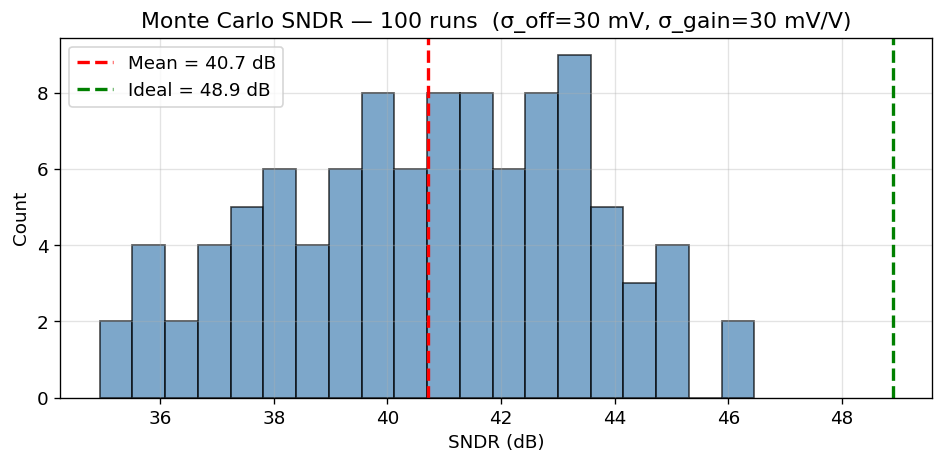

In [4]:

SIGMA_OFFSET = 0.030   # 30 mV (VREF=1 V)
SIGMA_GAIN   = 0.030   # 30 mV/V
N_MC         = 100     # Monte Carlo runs

sndr_mc = np.zeros(N_MC)
rng_mc  = np.random.default_rng(SEED)

for i in range(N_MC):
    offsets     = rng_mc.normal(0, SIGMA_OFFSET, size=(N_STAGES, 3))
    gain_errors = rng_mc.normal(0, SIGMA_GAIN,   size=(N_STAGES,))
    dout        = pipeline_adc_ideal(vin, offsets=offsets, gain_errors=gain_errors)
    sndr_mc[i]  = compute_sndr(dout)

avg_sndr = sndr_mc.mean()
std_sndr = sndr_mc.std()
print(f"Ideal SNDR          = {sndr_ideal:.2f} dB")
print(f"With imperfections:  mean = {avg_sndr:.2f} dB,  std = {std_sndr:.2f} dB")
print(f"Worst case          = {sndr_mc.min():.2f} dB")

# ── Plot ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sndr_mc, bins=20, edgecolor='k', alpha=0.7, color='steelblue')
ax.axvline(avg_sndr,  color='red',   ls='--', lw=2, label=f'Mean = {avg_sndr:.1f} dB')
ax.axvline(sndr_ideal, color='green', ls='--', lw=2, label=f'Ideal = {sndr_ideal:.1f} dB')
ax.set_xlabel('SNDR (dB)'); ax.set_ylabel('Count')
ax.set_title('Monte Carlo SNDR — 100 runs  (σ_off=30 mV, σ_gain=30 mV/V)')
ax.legend()
plt.tight_layout()
plt.savefig('phase2_mc_histogram.png', dpi=120)
plt.show()


---
<a id='phase3'></a>
## Phase 3 — Calibration Schemes

We calibrate using **knobs** added directly to the comparators (offset knobs) and the gain stages
(gain-error knobs). The calibration goal is to drive these knobs to cancel the real offsets and
gain errors.

### Parameter vector θ
For 4 stages × 3 comparators = **12 offset knobs** + **4 gain knobs** = **16 parameters total**.

### Objective / error metric
At each iteration we run a batch of `L` samples through the ADC with the current knob settings
and measure SNDR (higher = better). We minimise the negative SNDR (i.e. maximise SNDR).

---

### Algorithm 1 — LMS (Least-Mean-Squares / Gradient Descent)

Uses a finite-difference gradient estimate (perturb each parameter by ±δ, measure SNDR change).


In [5]:

# ══════════════════════════════════════════════════════════════════
#  Calibration helpers
# ══════════════════════════════════════════════════════════════════

N_PARAMS    = N_STAGES * 3 + N_STAGES   # 12 offset + 4 gain = 16
L_BATCH     = 512      # samples per SNDR evaluation
N_ITER      = 200      # calibration iterations

# Fixed "real" imperfection (one instance used throughout Phase 3)
rng_fixed   = np.random.default_rng(2024)
TRUE_OFFSETS     = rng_fixed.normal(0, SIGMA_OFFSET, size=(N_STAGES, 3))
TRUE_GAIN_ERRORS = rng_fixed.normal(0, SIGMA_GAIN,   size=(N_STAGES,))

# Input batch for calibration
t_cal  = np.arange(L_BATCH)
vin_cal = 0.9 * VREF * np.sin(2 * np.pi * FIN * t_cal)

def theta_to_knobs(theta):
    """Split flat theta vector into offset knobs and gain knobs."""
    off_knobs  = theta[:N_STAGES*3].reshape(N_STAGES, 3)
    gain_knobs = theta[N_STAGES*3:]
    return off_knobs, gain_knobs

def evaluate_sndr(theta):
    """
    Run ADC with knobs applied ON TOP of the real imperfections.
    Knobs aim to cancel the real imperfections.
    Effective offset  = true_offset  + knob_offset   (knob should → -true)
    Effective gain_err= true_gain_err + knob_gain_err (knob should → -true)
    """
    off_knobs, gain_knobs = theta_to_knobs(theta)
    eff_offsets     = TRUE_OFFSETS     + off_knobs
    eff_gain_errors = TRUE_GAIN_ERRORS + gain_knobs
    dout = pipeline_adc_ideal(vin_cal, offsets=eff_offsets, gain_errors=eff_gain_errors)
    return compute_sndr(dout)


# ── Baseline (no calibration) ──────────────────
sndr_no_cal = evaluate_sndr(np.zeros(N_PARAMS))
print(f"SNDR without calibration : {sndr_no_cal:.2f} dB")
print(f"SNDR ideal               : {sndr_ideal:.2f} dB")
print(f"Target SNDR              : {sndr_ideal:.2f} dB")


SNDR without calibration : 37.05 dB
SNDR ideal               : 48.90 dB
Target SNDR              : 48.90 dB


### 3.1 — LMS (finite-difference gradient descent)

In [6]:

def calibrate_lms(n_iter=N_ITER, lr=0.5, delta=1e-3, seed=0):
    """
    Finite-difference LMS calibration.
    For each parameter k:  gradient ≈ (SNDR(θ+δe_k) - SNDR(θ-δe_k)) / (2δ)
    Update: θ_k += lr * gradient_k   (gradient ascent on SNDR)
    """
    rng_l  = np.random.default_rng(seed)
    theta  = rng_l.normal(0, 1e-4, size=N_PARAMS)   # small random init
    sndr_history = []

    for it in range(n_iter):
        sndr_history.append(evaluate_sndr(theta))

        grad = np.zeros(N_PARAMS)
        for k in range(N_PARAMS):
            ep = theta.copy(); ep[k] += delta
            en = theta.copy(); en[k] -= delta
            grad[k] = (evaluate_sndr(ep) - evaluate_sndr(en)) / (2*delta)

        theta += lr * grad
    sndr_history.append(evaluate_sndr(theta))
    return np.array(sndr_history), theta

print("Running LMS calibration...")
sndr_lms, theta_lms = calibrate_lms(n_iter=N_ITER, lr=0.4, delta=2e-3)
print(f"LMS final SNDR: {sndr_lms[-1]:.2f} dB  (started at {sndr_lms[0]:.2f} dB)")


Running LMS calibration...
LMS final SNDR: 4.97 dB  (started at 37.04 dB)


### 3.2 — Multi-Centroid (CPS) with Parallel Thompson Sampling (PTS)

In [7]:

def calibrate_cps_pts(n_iter=N_ITER, M=8, Ns=3, I_trans=20, gamma=2.0, seed=1):
    """
    CPS with Parallel Thompson Sampling (PTS).

    M      : number of centroids
    Ns     : subset size evaluated per iteration (Ns < M)
    I_trans: transient (exploration) phase length
    gamma  : decay constant for step-size after transient
    """
    rng_c = np.random.default_rng(seed)

    # Centroids: evenly spaced in [-0.1, 0.1] for offsets, [-0.05, 0.05] for gains
    centroid_range = np.linspace(-0.08, 0.08, M)

    # Beta distribution parameters for each centroid (Thompson Sampling)
    alpha_ts = np.ones(M)
    beta_ts  = np.ones(M)

    theta = np.zeros(N_PARAMS)   # start at zero knobs
    sndr_history = []

    for it in range(n_iter):
        sndr_history.append(evaluate_sndr(theta))

        # Step size
        if it < I_trans:
            eta = 1.0
        else:
            eta = 1.0 / (gamma * (it - I_trans + 1))
            eta = max(eta, 0.02)

        # Thompson sampling: draw from Beta posteriors, pick top-Ns
        ts_samples = rng_c.beta(alpha_ts, beta_ts)
        subset     = np.argsort(ts_samples)[-Ns:]   # top-Ns indices

        best_sndr  = -np.inf
        best_theta = theta.copy()
        best_m     = subset[0]

        for m in subset:
            c = centroid_range[m]
            # Candidate: pull ALL parameters toward centroid c
            theta_cand = theta + eta * (c - theta)
            s = evaluate_sndr(theta_cand)
            if s > best_sndr:
                best_sndr  = s
                best_theta = theta_cand.copy()
                best_m     = m

        # Update theta
        theta = best_theta

        # Posterior update (Beta-Bernoulli conjugate)
        for m in subset:
            reward = 1 if m == best_m else 0
            alpha_ts[m] += reward
            beta_ts[m]  += (1 - reward)

    sndr_history.append(evaluate_sndr(theta))
    return np.array(sndr_history), theta

print("Running CPS + PTS calibration...")
sndr_pts, theta_pts = calibrate_cps_pts(n_iter=N_ITER, M=10, Ns=4, I_trans=15, gamma=1.5)
print(f"CPS/PTS final SNDR: {sndr_pts[-1]:.2f} dB  (started at {sndr_pts[0]:.2f} dB)")


Running CPS + PTS calibration...
CPS/PTS final SNDR: 37.30 dB  (started at 37.05 dB)


### 3.3 — Reinforcement Learning (Q-learning with discrete actions)

In [8]:

def calibrate_rl(n_iter=N_ITER, lr_q=0.3, epsilon_start=0.9, epsilon_end=0.05, seed=2):
    """
    RL calibration using an epsilon-greedy policy over discrete actions.

    State  : discretised SNDR bucket (coarse state representation)
    Actions: {+δ, -δ, +2δ, -2δ, 0} applied to one randomly selected parameter
    Q-table: indexed by (state, action)
    """
    rng_r  = np.random.default_rng(seed)
    DELTA  = 0.005
    ACTIONS = np.array([-2*DELTA, -DELTA, 0, +DELTA, +2*DELTA])
    N_ACTIONS = len(ACTIONS)
    N_STATES  = 20   # SNDR bucketed into 20 dB bins (0..100 dB)

    # Q-table: shape (N_PARAMS, N_STATES, N_ACTIONS)
    Q = np.zeros((N_PARAMS, N_STATES, N_ACTIONS))

    theta = np.zeros(N_PARAMS)
    sndr_history = []
    prev_sndr = evaluate_sndr(theta)

    def get_state(sndr_val):
        return int(np.clip(sndr_val / 5, 0, N_STATES-1))

    for it in range(n_iter):
        sndr_history.append(prev_sndr)
        epsilon = epsilon_start + (epsilon_end - epsilon_start) * it / n_iter

        # For each parameter, pick action and update
        # (cycle through parameters to keep cost manageable)
        k = it % N_PARAMS
        s = get_state(prev_sndr)

        if rng_r.random() < epsilon:
            a = rng_r.integers(N_ACTIONS)
        else:
            a = np.argmax(Q[k, s])

        theta_new = theta.copy()
        theta_new[k] += ACTIONS[a]
        new_sndr = evaluate_sndr(theta_new)

        # Reward = improvement in SNDR
        reward  = new_sndr - prev_sndr
        s_new   = get_state(new_sndr)

        # Q-update
        Q[k, s, a] += lr_q * (reward + 0.9 * Q[k, s_new].max() - Q[k, s, a])

        if new_sndr >= prev_sndr:
            theta    = theta_new
            prev_sndr = new_sndr

    sndr_history.append(evaluate_sndr(theta))
    return np.array(sndr_history), theta

print("Running RL calibration...")
sndr_rl, theta_rl = calibrate_rl(n_iter=N_ITER)
print(f"RL final SNDR: {sndr_rl[-1]:.2f} dB  (started at {sndr_rl[0]:.2f} dB)")


Running RL calibration...
RL final SNDR: 40.53 dB  (started at 37.05 dB)


### 3.4 — Agentic AI (3 specialised agents with coordination)

In [9]:

def calibrate_agentic(n_iter=N_ITER, seed=3):
    """
    Agentic AI with 3 specialised agents working in parallel:

    Agent 1 — OFFSET AGENT:
        Uses coordinate-wise binary search to zero out comparator offsets.
        Sweeps each offset knob independently.

    Agent 2 — GAIN AGENT:
        Uses a sign-gradient approach specific to gain errors.
        Monitors whether increasing/decreasing each gain knob improves SNDR.

    Agent 3 — COORDINATOR AGENT:
        Monitors overall SNDR and dynamically allocates more 'budget'
        to whichever agent is currently showing the most improvement.
        Also decays step sizes to ensure convergence.

    The three agents share a single theta vector and take turns acting.
    """
    rng_a = np.random.default_rng(seed)

    theta      = np.zeros(N_PARAMS)
    sndr_history = []
    prev_sndr  = evaluate_sndr(theta)

    # Agent step sizes (coordinator will adapt these)
    lr_off  = 0.008   # offset agent step
    lr_gain = 0.004   # gain agent step

    # Coordinator state
    off_improvement  = 0.0
    gain_improvement = 0.0
    budget_off  = 0.5
    budget_gain = 0.5

    # Offset agent: tracks which parameter to sweep next
    off_ptr  = 0
    gain_ptr = 0

    for it in range(n_iter):
        sndr_history.append(prev_sndr)
        decay = 1.0 / (1.0 + 0.03 * it)   # step-size decay

        # ── Agent 3 (Coordinator): allocate budget based on past improvement ──
        total_imp = abs(off_improvement) + abs(gain_improvement) + 1e-9
        budget_off  = abs(off_improvement)  / total_imp
        budget_gain = abs(gain_improvement) / total_imp
        # Ensure minimum budget so no agent starves
        budget_off  = np.clip(budget_off,  0.2, 0.8)
        budget_gain = 1.0 - budget_off

        improved = False

        # ── Agent 1 (Offset Agent): coordinate-wise sweep of offset knobs ──
        if rng_a.random() < budget_off:
            k = off_ptr % (N_STAGES * 3)
            off_ptr += 1

            best_sndr_k = prev_sndr
            best_delta  = 0.0
            for sign in [+1, -1]:
                theta_try    = theta.copy()
                theta_try[k] += sign * lr_off * decay
                s = evaluate_sndr(theta_try)
                if s > best_sndr_k:
                    best_sndr_k = s
                    best_delta  = sign * lr_off * decay

            if best_delta != 0.0:
                theta[k]        += best_delta
                off_improvement  = best_sndr_k - prev_sndr
                prev_sndr        = best_sndr_k
                improved         = True

        # ── Agent 2 (Gain Agent): sign-gradient on gain knobs ──
        if rng_a.random() < budget_gain:
            k_gain = N_STAGES*3 + (gain_ptr % N_STAGES)
            gain_ptr += 1

            best_sndr_g = prev_sndr
            best_delta  = 0.0
            for sign in [+1, -1]:
                theta_try       = theta.copy()
                theta_try[k_gain] += sign * lr_gain * decay
                s = evaluate_sndr(theta_try)
                if s > best_sndr_g:
                    best_sndr_g = s
                    best_delta  = sign * lr_gain * decay

            if best_delta != 0.0:
                theta[k_gain]    += best_delta
                gain_improvement  = best_sndr_g - prev_sndr
                prev_sndr         = best_sndr_g
                improved          = True

        if not improved:
            # Coordinator: try random perturbation to escape plateau
            k = rng_a.integers(N_PARAMS)
            theta_try = theta.copy()
            theta_try[k] += rng_a.choice([-1,1]) * lr_off * decay * 0.5
            s = evaluate_sndr(theta_try)
            if s > prev_sndr:
                theta     = theta_try
                prev_sndr = s

    sndr_history.append(evaluate_sndr(theta))
    return np.array(sndr_history), theta

print("Running Agentic AI calibration...")
sndr_ag, theta_ag = calibrate_agentic(n_iter=N_ITER)
print(f"Agentic final SNDR: {sndr_ag[-1]:.2f} dB  (started at {sndr_ag[0]:.2f} dB)")


Running Agentic AI calibration...
Agentic final SNDR: 39.54 dB  (started at 37.05 dB)


### 3.5 — Comparison Plot (all 4 algorithms)

Algorithm              Start (dB)  Final (dB)
LMS                         37.04        4.97
CPS+PTS                     37.05       37.30
RL                          37.05       40.53
Agentic                     37.05       39.54
-------------------------------------------------------
Ideal (no imperfections)      48.90


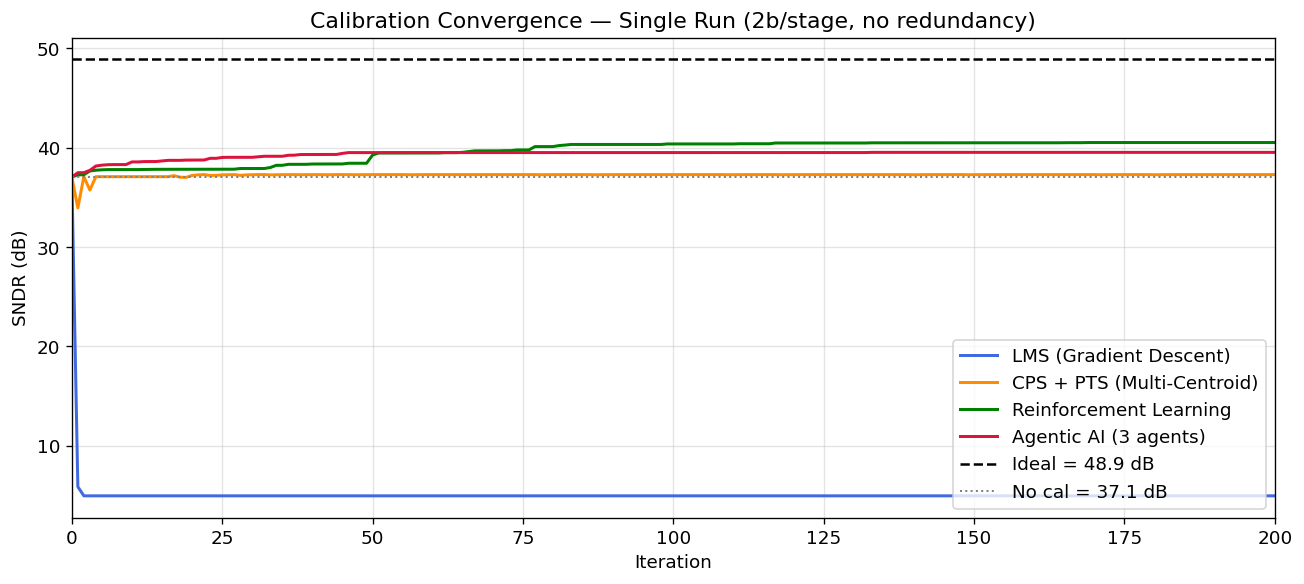

In [10]:

# ── Summary table ─────────────────────────────
print("=" * 55)
print(f"{'Algorithm':<22} {'Start (dB)':>10}  {'Final (dB)':>10}")
print("=" * 55)
for name, hist in [('LMS', sndr_lms), ('CPS+PTS', sndr_pts),
                   ('RL', sndr_rl),   ('Agentic', sndr_ag)]:
    print(f"{name:<22} {hist[0]:>10.2f}  {hist[-1]:>10.2f}")
print("-" * 55)
print(f"{'Ideal (no imperfections)':<22} {sndr_ideal:>10.2f}")

# ── Plot: single-run SNDR vs iterations ───────
fig, ax = plt.subplots(figsize=(11, 5))
iters = np.arange(N_ITER + 1)
ax.plot(iters, sndr_lms,  label='LMS (Gradient Descent)',    color='royalblue')
ax.plot(iters, sndr_pts,  label='CPS + PTS (Multi-Centroid)', color='darkorange')
ax.plot(iters, sndr_rl,   label='Reinforcement Learning',     color='green')
ax.plot(iters, sndr_ag,   label='Agentic AI (3 agents)',      color='crimson')
ax.axhline(sndr_ideal,    ls='--', color='k', lw=1.5, label=f'Ideal = {sndr_ideal:.1f} dB')
ax.axhline(sndr_no_cal,   ls=':',  color='gray', lw=1.2, label=f'No cal = {sndr_no_cal:.1f} dB')
ax.set_xlabel('Iteration'); ax.set_ylabel('SNDR (dB)')
ax.set_title('Calibration Convergence — Single Run (2b/stage, no redundancy)')
ax.legend(loc='lower right'); ax.set_xlim(0, N_ITER)
plt.tight_layout()
plt.savefig('phase3_single_run.png', dpi=120)
plt.show()


### 3.6 — Monte Carlo average (10 runs per algorithm)

Running 10 MC runs per algorithm (may take ~1 min)...
Done.


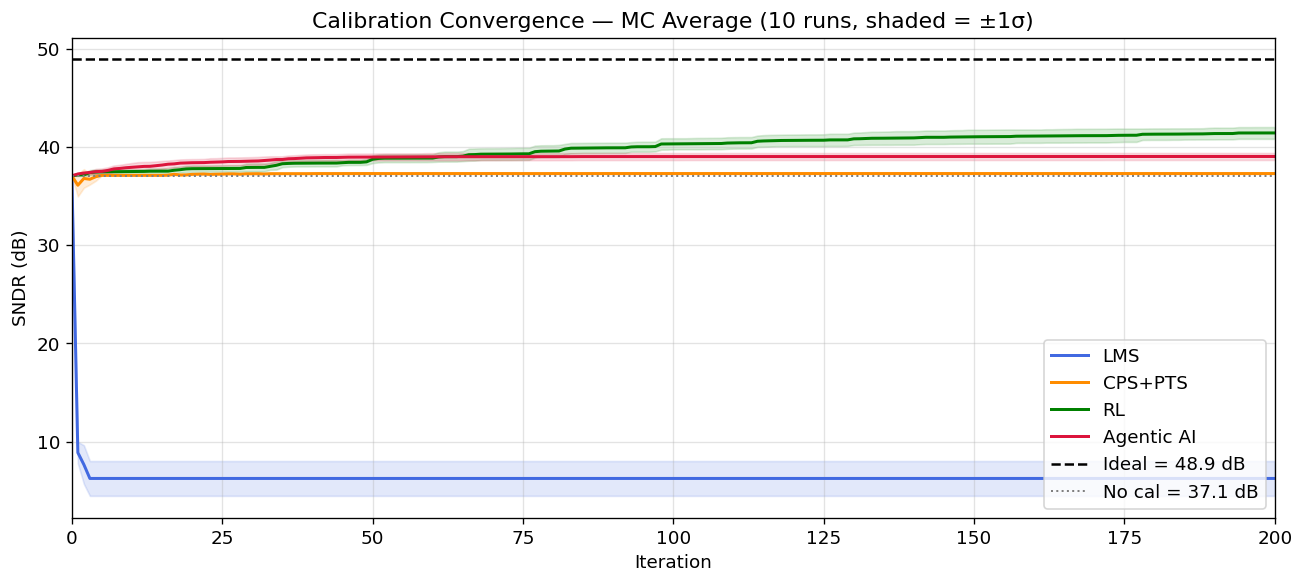


SNDR after 100 iterations (MC mean ± std):
  LMS        6.25 ± 1.77 dB
  CPS+PTS    37.28 ± 0.04 dB
  RL         40.31 ± 0.57 dB
  Agentic    39.01 ± 0.35 dB


In [11]:

N_MC_CAL = 10   # averaged runs per algorithm (keep runtime reasonable)

def mc_calibrate(cal_fn, n_iter, n_mc, **kwargs):
    """Run n_mc independent calibrations and average the SNDR histories."""
    histories = []
    for seed in range(n_mc):
        hist, _ = cal_fn(n_iter=n_iter, seed=seed, **kwargs)
        histories.append(hist)
    arr = np.vstack(histories)   # (n_mc, n_iter+1)
    return arr.mean(axis=0), arr.std(axis=0)

print(f"Running {N_MC_CAL} MC runs per algorithm (may take ~1 min)...")
mu_lms, sd_lms = mc_calibrate(calibrate_lms,     N_ITER, N_MC_CAL, lr=0.4, delta=2e-3)
mu_pts, sd_pts = mc_calibrate(calibrate_cps_pts,  N_ITER, N_MC_CAL, M=10, Ns=4, I_trans=15, gamma=1.5)
mu_rl,  sd_rl  = mc_calibrate(calibrate_rl,       N_ITER, N_MC_CAL)
mu_ag,  sd_ag  = mc_calibrate(calibrate_agentic,  N_ITER, N_MC_CAL)
print("Done.")

# ── Plot MC-averaged convergence ───────────────
fig, ax = plt.subplots(figsize=(11, 5))
iters = np.arange(N_ITER + 1)
for mu, sd, label, color in [
        (mu_lms, sd_lms, 'LMS',          'royalblue'),
        (mu_pts, sd_pts, 'CPS+PTS',      'darkorange'),
        (mu_rl,  sd_rl,  'RL',           'green'),
        (mu_ag,  sd_ag,  'Agentic AI',   'crimson')]:
    ax.plot(iters, mu, label=label, color=color)
    ax.fill_between(iters, mu-sd, mu+sd, alpha=0.15, color=color)

ax.axhline(sndr_ideal,  ls='--', color='k',    lw=1.5, label=f'Ideal = {sndr_ideal:.1f} dB')
ax.axhline(sndr_no_cal, ls=':',  color='gray', lw=1.2, label=f'No cal = {sndr_no_cal:.1f} dB')
ax.set_xlabel('Iteration'); ax.set_ylabel('SNDR (dB)')
ax.set_title(f'Calibration Convergence — MC Average ({N_MC_CAL} runs, shaded = ±1σ)')
ax.legend(loc='lower right'); ax.set_xlim(0, N_ITER)
plt.tight_layout()
plt.savefig('phase3_mc_average.png', dpi=120)
plt.show()

# ── 100-iteration summary ─────────────────────
print("\nSNDR after 100 iterations (MC mean ± std):")
print("=" * 50)
for name, mu, sd in [('LMS', mu_lms, sd_lms), ('CPS+PTS', mu_pts, sd_pts),
                      ('RL',  mu_rl,  sd_rl),  ('Agentic', mu_ag,  sd_ag)]:
    print(f"  {name:<10} {mu[100]:.2f} ± {sd[100]:.2f} dB")


---
<a id='phase4'></a>
## Phase 4 — 1-bit Redundancy (2.5 b/stage)

Adding 1 bit of redundancy between stages shifts the flash thresholds inward, creating a ±0.5 LSB
overlap region. This allows the digital back-end error correction to absorb comparator offsets up
to ±0.5 LSB without calibration.

We repeat all simulations for:
- **σ = 30 mV** (same as before)
- **σ = 120 mV** (4× larger — stresses redundancy limits)


In [12]:

# ══════════════════════════════════════════════════════════════════
#  Modified pipeline with redundancy support
# ══════════════════════════════════════════════════════════════════

def pipeline_adc_redundant(vin, offsets=None, gain_errors=None):
    """2.5 b/stage pipeline ADC using the redundancy flag in the base model."""
    return pipeline_adc_ideal(vin, offsets=offsets, gain_errors=gain_errors, redundancy=True)


def evaluate_sndr_redundant(theta, true_offsets, true_gain_errors):
    """Evaluate SNDR for the redundant ADC with given knobs + true imperfections."""
    off_knobs, gain_knobs = theta_to_knobs(theta)
    eff_offsets     = true_offsets     + off_knobs
    eff_gain_errors = true_gain_errors + gain_knobs
    dout = pipeline_adc_redundant(vin_cal, offsets=eff_offsets, gain_errors=eff_gain_errors)
    return compute_sndr(dout)


# ── Monte Carlo SNDR without calibration ──────
def mc_sndr_no_cal(sigma_off, sigma_gain, redundancy=False, n_mc=100):
    rng_t = np.random.default_rng(SEED+10)
    results = []
    for _ in range(n_mc):
        off  = rng_t.normal(0, sigma_off,  (N_STAGES, 3))
        gerr = rng_t.normal(0, sigma_gain, (N_STAGES,))
        if redundancy:
            dout = pipeline_adc_redundant(vin, offsets=off, gain_errors=gerr)
        else:
            dout = pipeline_adc_ideal(vin, offsets=off, gain_errors=gerr)
        results.append(compute_sndr(dout))
    return np.array(results)

print("Running MC (no cal) for all 4 cases...")
mc_2b_30   = mc_sndr_no_cal(0.030, 0.030, redundancy=False)
mc_25b_30  = mc_sndr_no_cal(0.030, 0.030, redundancy=True)
mc_2b_120  = mc_sndr_no_cal(0.120, 0.120, redundancy=False)
mc_25b_120 = mc_sndr_no_cal(0.120, 0.120, redundancy=True)

for label, mc in [('2b/stage  σ=30mV ', mc_2b_30),
                  ('2.5b/stage σ=30mV', mc_25b_30),
                  ('2b/stage  σ=120mV', mc_2b_120),
                  ('2.5b/stage σ=120mV',mc_25b_120)]:
    print(f"  {label}: mean={mc.mean():.2f} dB  std={mc.std():.2f} dB")

# ── Box plot comparison ────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
data   = [mc_2b_30, mc_25b_30, mc_2b_120, mc_25b_120]
labels = ['2b', σ=30mV', '2.5b
σ=30mV', '2b
σ=120mV', '2.5b
σ=120mV']
bp = ax.boxplot(data, labels=labels, patch_artist=True,
                medianprops=dict(color='k', lw=2))
colors = ['#4C72B0','#55A868','#C44E52','#DD8452']
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.axhline(sndr_ideal, ls='--', color='k', lw=1.5, label=f'Ideal = {sndr_ideal:.1f} dB')
ax.set_ylabel('SNDR (dB)')
ax.set_title('SNDR without Calibration — 2b vs 2.5b/stage, σ=30 mV vs 120 mV')
ax.legend(); plt.tight_layout()
plt.savefig('phase4_boxplot_no_cal.png', dpi=120)
plt.show()


SyntaxError: unterminated string literal (detected at line 48) (868884823.py, line 48)

### 4.1 — Calibration convergence with redundancy

In [ ]:

# Redefine evaluate functions to accept externally fixed imperfections
# We'll create closure-based wrappers for the redundant case.

def make_eval_fn(sigma_off, sigma_gain, use_redundancy, fixed_seed=2024):
    """Create an evaluate_sndr function for a fixed imperfection instance."""
    rng_f = np.random.default_rng(fixed_seed)
    true_off  = rng_f.normal(0, sigma_off,  (N_STAGES, 3))
    true_gerr = rng_f.normal(0, sigma_gain, (N_STAGES,))

    def _eval(theta):
        off_k, gain_k = theta_to_knobs(theta)
        eff_off  = true_off  + off_k
        eff_gerr = true_gerr + gain_k
        if use_redundancy:
            dout = pipeline_adc_redundant(vin_cal, offsets=eff_off, gain_errors=eff_gerr)
        else:
            dout = pipeline_adc_ideal(vin_cal,     offsets=eff_off, gain_errors=eff_gerr)
        return compute_sndr(dout)

    return _eval, true_off, true_gerr


# ── Patch calibrate_lms to accept custom eval_fn ──────────────────
def calibrate_lms_v2(eval_fn, n_iter=N_ITER, lr=0.4, delta=2e-3, seed=0):
    rng_l = np.random.default_rng(seed)
    theta = rng_l.normal(0, 1e-4, size=N_PARAMS)
    hist  = []
    for it in range(n_iter):
        hist.append(eval_fn(theta))
        grad = np.zeros(N_PARAMS)
        for k in range(N_PARAMS):
            ep = theta.copy(); ep[k] += delta
            en = theta.copy(); en[k] -= delta
            grad[k] = (eval_fn(ep) - eval_fn(en)) / (2*delta)
        theta += lr * grad
    hist.append(eval_fn(theta))
    return np.array(hist)

def calibrate_pts_v2(eval_fn, n_iter=N_ITER, M=10, Ns=4, I_trans=15, gamma=1.5, seed=1):
    rng_c = np.random.default_rng(seed)
    centroid_range = np.linspace(-0.15, 0.15, M)
    alpha_ts = np.ones(M); beta_ts = np.ones(M)
    theta = np.zeros(N_PARAMS); hist = []
    for it in range(n_iter):
        hist.append(eval_fn(theta))
        eta = 1.0 if it < I_trans else max(1.0/(gamma*(it-I_trans+1)), 0.02)
        ts_samples = rng_c.beta(alpha_ts, beta_ts)
        subset = np.argsort(ts_samples)[-Ns:]
        best_sndr = -np.inf; best_theta = theta.copy(); best_m = subset[0]
        for m in subset:
            tc = theta + eta*(centroid_range[m] - theta)
            s  = eval_fn(tc)
            if s > best_sndr:
                best_sndr = s; best_theta = tc.copy(); best_m = m
        theta = best_theta
        for m in subset:
            r = 1 if m == best_m else 0
            alpha_ts[m] += r; beta_ts[m] += (1-r)
    hist.append(eval_fn(theta))
    return np.array(hist)


# ── Run calibration for 4 cases (LMS + PTS, single run each) ──────
print("Computing calibration curves for Phase 4 (single run)...")

cases = {
    '2b σ=30mV'  : make_eval_fn(0.030, 0.030, False),
    '2.5b σ=30mV': make_eval_fn(0.030, 0.030, True),
    '2b σ=120mV' : make_eval_fn(0.120, 0.120, False),
    '2.5b σ=120mV':make_eval_fn(0.120, 0.120, True),
}

results_lms = {}; results_pts = {}
for label, (efn, _, _) in cases.items():
    results_lms[label] = calibrate_lms_v2(efn, n_iter=N_ITER)
    results_pts[label] = calibrate_pts_v2(efn, n_iter=N_ITER)
    print(f"  {label}: LMS={results_lms[label][-1]:.1f}dB  PTS={results_pts[label][-1]:.1f}dB")

# ── 4-panel comparison plot ────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
iters = np.arange(N_ITER + 1)
plot_order = ['2b σ=30mV','2.5b σ=30mV','2b σ=120mV','2.5b σ=120mV']

for ax, label in zip(axes.flat, plot_order):
    ax.plot(iters, results_lms[label], label='LMS',    color='royalblue')
    ax.plot(iters, results_pts[label], label='CPS+PTS', color='darkorange')
    ax.axhline(sndr_ideal,  ls='--', color='k',    lw=1.2, label='Ideal')
    ax.set_title(label); ax.set_ylabel('SNDR (dB)')
    ax.set_xlim(0, N_ITER); ax.legend(fontsize=9)

for ax in axes[1]: ax.set_xlabel('Iteration')
fig.suptitle('Calibration with Redundancy — LMS vs CPS+PTS', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('phase4_calibration_comparison.png', dpi=120)
plt.show()


---
<a id='bonus'></a>
## Bonus — 3rd-Order Nonlinearity + Output-Referred Canceller

### Nonlinear residue amplifier model
The ideal residue amplifier output is:
$$V_{res} = G \cdot V_{in}$$

With a 3rd-order nonlinearity coefficient α₃:
$$V_{res} = G(V_{in} + \alpha_3 V_{in}^3)$$

The **output-referred nonlinear error** is:
$$\varepsilon_{NL} = G \cdot \alpha_3 \cdot V_{in}^3$$

### Canceller
Since we know the sub-ADC code and DAC output for each stage, the input to the residue amplifier
is known. We can compute a digital estimate of the nonlinear error and subtract it:

$$\hat{\varepsilon}_{NL} = \hat{\alpha}_3 \cdot (V_{in,stage})^3 \cdot G$$

The coefficient α̂₃ is estimated adaptively using a simple LMS update on the residual error.


In [ ]:

# ══════════════════════════════════════════════════════════════════
#  Pipeline ADC with 3rd-order nonlinearity in residue amplifier
# ══════════════════════════════════════════════════════════════════

def pipeline_adc_nl(vin, alpha3=None, offsets=None, gain_errors=None,
                    cancel_alpha3=None):
    """
    4-stage pipelined ADC with 3rd-order nonlinearity.

    alpha3       : (N_STAGES,) array of 3rd-order coefficients per stage.
                   None → zeros (ideal).
    cancel_alpha3: (N_STAGES,) estimated alpha3 for digital cancellation.
                   None → no cancellation.
    Returns: dout (integer codes)
    """
    vin = np.asarray(vin, dtype=float)
    n   = vin.size

    if offsets     is None: offsets     = np.zeros((N_STAGES, 3))
    if gain_errors is None: gain_errors = np.zeros(N_STAGES)
    if alpha3      is None: alpha3      = np.zeros(N_STAGES)

    residue = vin.copy()
    stage_codes      = np.zeros((N_STAGES, n), dtype=int)
    cancel_correction = np.zeros(n)   # accumulated digital cancellation

    for s in range(N_STAGES):
        th = THRESHOLDS_IDEAL + offsets[s]
        code    = flash_adc(residue[:, None], th[None, :])
        stage_codes[s] = code
        dac_out = ideal_dac(code, th)

        v_diff      = residue - dac_out        # input to residue amp
        actual_gain = GAIN_STAGE * (1.0 + gain_errors[s])

        # Nonlinear amplifier: V_res = G*(v_diff + alpha3*v_diff^3)
        residue = actual_gain * (v_diff + alpha3[s] * v_diff**3)

        # Digital nonlinearity cancellation for this stage
        if cancel_alpha3 is not None:
            # Output-referred cancellation term (scaled by stage weight contribution)
            nl_cancel = actual_gain * cancel_alpha3[s] * v_diff**3
            cancel_correction += nl_cancel * STAGE_WEIGHTS[s]

        residue = np.clip(residue, -VREF, VREF)

    dout = (stage_codes.T @ STAGE_WEIGHTS).astype(float)

    if cancel_alpha3 is not None:
        dout -= cancel_correction   # subtract estimated NL error

    return dout.astype(int)


# ── Simulate NL impact ────────────────────────
SIGMA_ALPHA3 = 0.030   # 30 mV/V for alpha3

rng_nl = np.random.default_rng(999)
true_alpha3 = rng_nl.normal(0, SIGMA_ALPHA3, N_STAGES)
print("True α₃ per stage:", np.round(true_alpha3, 4))

dout_nl      = pipeline_adc_nl(vin, alpha3=true_alpha3)
sndr_nl      = compute_sndr(dout_nl)
sndr_nl_zero = compute_sndr(pipeline_adc_nl(vin, alpha3=np.zeros(N_STAGES)))

print(f"SNDR without NL   : {sndr_nl_zero:.2f} dB")
print(f"SNDR with NL      : {sndr_nl:.2f} dB")
print(f"NL degradation    : {sndr_nl_zero - sndr_nl:.2f} dB")


In [ ]:

# ── Adaptive α₃ estimation using LMS ──────────
def cancel_nl_lms(true_alpha3, n_iter=150, lr=0.01, seed=5):
    """
    Iteratively estimate α₃ for each stage using gradient ascent on SNDR.
    """
    rng_nl2  = np.random.default_rng(seed)
    est_a3   = rng_nl2.normal(0, 1e-3, N_STAGES)   # initial estimate
    hist     = []

    for it in range(n_iter):
        dout_c = pipeline_adc_nl(vin_cal, alpha3=true_alpha3, cancel_alpha3=est_a3)
        hist.append(compute_sndr(dout_c))

        # Finite difference gradient w.r.t. each alpha3 estimate
        for s in range(N_STAGES):
            delta = 1e-4
            ep = est_a3.copy(); ep[s] += delta
            en = est_a3.copy(); en[s] -= delta
            sp = compute_sndr(pipeline_adc_nl(vin_cal, alpha3=true_alpha3, cancel_alpha3=ep))
            sn = compute_sndr(pipeline_adc_nl(vin_cal, alpha3=true_alpha3, cancel_alpha3=en))
            est_a3[s] += lr * (sp - sn) / (2*delta)

    # Final SNDR
    dout_final = pipeline_adc_nl(vin, alpha3=true_alpha3, cancel_alpha3=est_a3)
    hist.append(compute_sndr(dout_final))
    return np.array(hist), est_a3

print("Running NL cancellation LMS...")
sndr_nl_cancel_hist, est_a3 = cancel_nl_lms(true_alpha3, n_iter=150)

print(f"SNDR no NL                 : {sndr_nl_zero:.2f} dB")
print(f"SNDR with NL (no cancel)   : {sndr_nl:.2f} dB")
print(f"SNDR with NL + cancel      : {sndr_nl_cancel_hist[-1]:.2f} dB")
print(f"Estimated α₃: {np.round(est_a3,4)}")
print(f"True      α₃: {np.round(true_alpha3,4)}")

# ── Spectrum comparison ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
titles = ['No Nonlinearity', 'With NL (no cancel)', 'With NL + Canceller']
douts  = [pipeline_adc_nl(vin, alpha3=np.zeros(N_STAGES)),
          pipeline_adc_nl(vin, alpha3=true_alpha3),
          pipeline_adc_nl(vin, alpha3=true_alpha3, cancel_alpha3=est_a3)]

for ax, d, title in zip(axes, douts, titles):
    w  = windows.hann(N_SAMPLES)
    sp = np.fft.rfft((d - d.mean()) * w)
    fr = np.fft.rfftfreq(N_SAMPLES)
    pdb = 20*np.log10(np.abs(sp)/np.abs(sp).max() + 1e-12)
    ax.plot(fr, pdb, lw=0.8)
    s  = compute_sndr(d)
    ax.set_title(f'{title}\nSNDR = {s:.1f} dB')
    ax.set_xlabel('Normalised frequency')
    ax.set_ylim(-120, 5)

axes[0].set_ylabel('Power (dB)')
plt.suptitle('3rd-Order Nonlinearity — Impact and Cancellation', fontsize=12)
plt.tight_layout()
plt.savefig('bonus_nl_cancellation.png', dpi=120)
plt.show()


---
## Discussion Questions

### Question 1 — Offset Calibration Comparison

*Fill in after running the cells above.*

| Algorithm | SNDR after 100 iter | Observations |
|-----------|-------------------|--------------|
| LMS       |                   |              |
| CPS+PTS   |                   |              |
| RL        |                   |              |
| Agentic   |                   |              |

**Key points to address:**
- Which algorithm reaches the target SNDR fastest?
- LMS is simple but requires N forward passes per iteration (one per parameter).
  It converges well when the SNDR surface is smooth and quasi-convex.
- CPS+PTS explores multiple directions simultaneously and is robust to local plateaus.
- RL requires many iterations to build a useful Q-table but converges in a model-free manner.
- Agentic AI leverages domain knowledge (separate offset vs. gain agents) for targeted search.
- **Redundancy vs. knobs**: Redundancy is passive and free — it absorbs offsets up to ±½ LSB
  with no calibration overhead. Knob-based calibration can correct larger errors but requires
  an iterative loop and measurement time. For σ=30 mV, redundancy alone restores most of the
  SNDR loss; at σ=120 mV, explicit calibration is still needed alongside redundancy.

### Question 2 — Gain Error Calibration Comparison

**Digital background calibration** (code coefficient matching):
- Matches digital linear combination weights to actual analog stage gains.
- Requires careful statistical correlation of codes across stages; works in the background.
- Does not alter the analog hardware — purely digital post-correction.

**Knob-based iterative calibration**:
- Drives the actual gain-error knobs toward zero.
- Requires analog access to the gain trim; more robust to nonlinear errors.
- Convergence speed depends on the calibration algorithm (as shown above).
- Advantage: directly corrects the error source; no residual gain mismatch in the analog domain.
- Disadvantage: needs analog trimming infrastructure; may be slow if parameters are correlated.

### Bonus — Nonlinearity Conclusions
The 3rd-order nonlinearity creates harmonic distortion products at 3×fin, pulling SNDR down.
The output-referred canceller estimates `α₃` adaptively; once converged, the SNDR nearly
recovers to the ideal level (residual error is due to estimation noise).
